<a href="https://colab.research.google.com/github/diak224-dot/Machine-Learning-Projects/blob/main/DIAK_test2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**TP 2 : Réseaux de Neurones Artificiels (ANN)**

## Objectif

L'objectif de ce TP est de mettre en œuvre un réseau de neurones artificiel (ANN) pour résoudre un problème de classification binaire à partir du dataset Breast Cancer Wisconsin.

Nous allons :

- Charger et explorer les données
- Préparer les données
- Normaliser les variables
- Construire un réseau de neurones
- Entraîner le modèle
- Évaluer les performances
- Produire des prédictions
- Analyser la matrice de confusion

**Partie 1 : Chargement du Dataset**

In [2]:
# =========================================================
# Importation des bibliothèques
# =========================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [3]:
# Chargement du dataset

data = load_breast_cancer()

X = data.data
y = data.target

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

print("\nClasses présentes :", np.unique(y))
print("Noms des classes :", data.target_names)

Dimensions de X : (569, 30)
Dimensions de y : (569,)

Classes présentes : [0 1]
Noms des classes : ['malignant' 'benign']


# Réponses aux questions

### Combien d'observations contient le dataset ?

Le dataset contient 569 observations.

### Combien de variables possède chaque observation ?

Chaque observation est décrite par 30 variables numériques.

### Quelle est la différence entre X et y ?

- X contient les variables explicatives.
- y contient la classe cible à prédire.

### Pourquoi ce problème est-il une classification binaire ?

Parce qu'il existe seulement deux classes :

- Malignant (tumeur maligne)
- Benign (tumeur bénigne)

##**Partie 2 : Séparation Train/Test**

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train :", X_train.shape)
print("X_test :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

X_train : (455, 30)
X_test : (114, 30)
y_train : (455,)
y_test : (114,)


# Réponses aux questions

### Pourquoi séparer les données ?

Pour évaluer les performances du modèle sur des données jamais vues.

### Quel est le rôle de test_size=0.2 ?

20 % des données sont réservées pour le test.

### Pourquoi utiliser stratify=y ?

Pour conserver les mêmes proportions de classes dans les ensembles d'entraînement et de test.

##**Partie 3 : Normalisation**

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Moyenne globale :", np.mean(X_train_scaled))
print("Écart-type global :", np.std(X_train_scaled))

Moyenne globale : -1.145197083276352e-16
Écart-type global : 1.0


# Réponses aux questions

### Que signifie normaliser les données ?

La normalisation consiste à centrer les données autour de 0 et à les réduire pour obtenir un écart-type proche de 1.

### Pourquoi normaliser ?

Les réseaux de neurones convergent plus rapidement lorsque les variables sont sur la même échelle.

### Pourquoi fit_transform sur train et transform sur test ?

Pour éviter toute fuite d'information provenant des données de test.

##**Partie 4 : Construction du Réseau ANN**

In [6]:
model = Sequential()

model.add(Dense(
    16,
    activation='relu',
    input_shape=(X_train_scaled.shape[1],)
))

model.add(Dense(
    8,
    activation='relu'
))

model.add(Dense(
    1,
    activation='sigmoid'
))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

# Réponses aux questions

### Pourquoi la couche d'entrée dépend du nombre de variables ?

Parce qu'un neurone d'entrée est associé à chaque variable du dataset.

### Quel est le rôle des couches cachées ?

Elles apprennent des relations complexes entre les variables.

### Pourquoi ReLU ?

ReLU est rapide à calculer et réduit les problèmes de disparition du gradient.

### Pourquoi Sigmoid ?

Elle produit une probabilité comprise entre 0 et 1 adaptée à une classification binaire.

##**Partie 5 : Compilation**

In [7]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Réponses aux questions

### Quel est le rôle de la fonction de perte ?

Mesurer l'erreur entre les prédictions et les vraies classes.

### Pourquoi binary_crossentropy ?

Parce qu'il s'agit d'une classification binaire.

### Quel est le rôle d'Adam ?

Optimiser les poids du réseau pour réduire l'erreur.

### Que mesure accuracy ?

Le pourcentage de prédictions correctes.

##**Partie 6 : Entraînement**

In [8]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.6429 - loss: 0.6225 - val_accuracy: 0.6154 - val_loss: 0.6039
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7445 - loss: 0.5124 - val_accuracy: 0.7473 - val_loss: 0.5186
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8434 - loss: 0.4312 - val_accuracy: 0.8242 - val_loss: 0.4515
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9038 - loss: 0.3641 - val_accuracy: 0.9121 - val_loss: 0.3905
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9286 - loss: 0.3024 - val_accuracy: 0.9451 - val_loss: 0.3247
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9396 - loss: 0.2469 - val_accuracy: 0.9560 - val_loss: 0.2621
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9560 - loss: 0.1999 - val_accuracy: 0.9451 - val_loss: 0.2136
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9670 - loss: 0.1651 - val_accuracy: 0.9560 - val

# Réponses aux questions

### Qu'est-ce qu'une époque ?

Une époque correspond à un passage complet sur l'ensemble d'entraînement.

### Quel est le rôle du batch_size ?

Les données sont traitées par petits groupes pour accélérer l'apprentissage.

### Pourquoi utiliser un ensemble de validation ?

Pour surveiller les performances durant l'entraînement.

### Que se passe-t-il si le nombre d'époques est trop élevé ?

Le modèle risque de surapprendre les données d'entraînement.

##**Partie 7 : Courbe de perte**

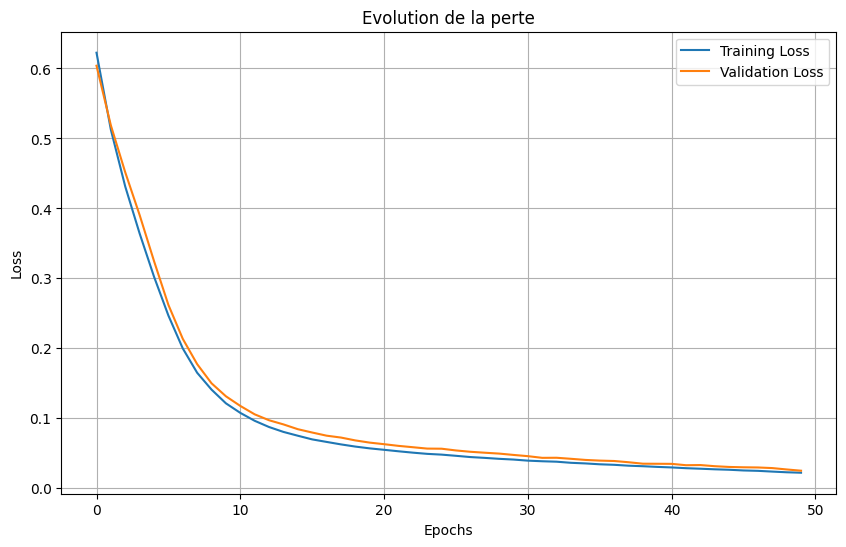

In [9]:
plt.figure(figsize=(10,6))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Evolution de la perte")
plt.legend()
plt.grid(True)

plt.show()

# Réponses aux questions

### Que représente la courbe de perte ?

L'évolution de l'erreur du modèle durant l'entraînement.

### Comment savoir si le modèle apprend ?

Les courbes loss et val_loss diminuent progressivement.

### Comment détecter un surapprentissage ?

Lorsque loss continue à diminuer mais val_loss augmente.

### Pourquoi val_loss est importante ?

Elle mesure les performances sur des données non utilisées directement pour l'apprentissage.

##**Partie 8 : Évaluation**

In [10]:
test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test
)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9649 - loss: 0.0932
Test Loss : 0.09317011386156082
Test Accuracy : 0.9649122953414917


# Réponses aux questions

### Pourquoi évaluer sur les données de test ?

Pour vérifier la capacité de généralisation du modèle.

### Différence entre accuracy train et test ?

L'accuracy train est calculée sur les données apprises.

L'accuracy test est calculée sur des données inédites.

### Que signifie une accuracy élevée ?

Le modèle réalise beaucoup de bonnes prédictions.

### Est-elle suffisante ?

Non. Il faut aussi analyser la précision, le rappel et le F1-score.

##**Partie 9 : Rapport de Classification**

In [11]:
y_pred_prob = model.predict(X_test_scaled)

y_pred = (y_pred_prob >= 0.5).astype(int).ravel()

print("Accuracy :", accuracy_score(y_test, y_pred))

print("\nRapport de classification :")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=data.target_names
    )
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Accuracy : 0.9649122807017544

Rapport de classification :
              precision    recall  f1-score   support

   malignant       0.93      0.98      0.95        42
      benign       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



# Réponses aux questions

### Pourquoi le modèle retourne des probabilités ?

Parce que la fonction sigmoid produit des valeurs entre 0 et 1.

### Quel est le rôle du seuil 0.5 ?

Transformer les probabilités en classes.

### Différence entre précision, rappel et F1-score ?

- Précision : qualité des prédictions positives.
- Rappel : capacité à retrouver tous les positifs.
- F1-score : compromis entre précision et rappel.

### Pourquoi utiliser le F1-score ?

Il donne une évaluation équilibrée des performances.

##**Partie 10 : Matrice de Confusion**

Matrice de confusion :
[[41  1]
 [ 3 69]]


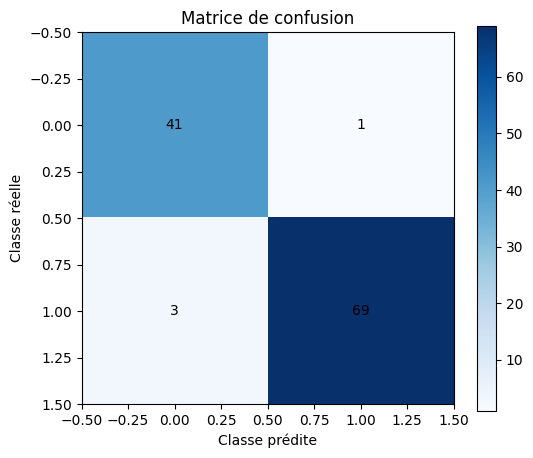

In [12]:
cm = confusion_matrix(y_test, y_pred)

print("Matrice de confusion :")
print(cm)

plt.figure(figsize=(6,5))

plt.imshow(cm, cmap='Blues')

plt.title("Matrice de confusion")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")

plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center'
        )

plt.show()

# Réponses aux questions

### Que représente la matrice de confusion ?

La comparaison entre les classes réelles et prédites.

### Différence entre bonne et mauvaise classification ?

Une bonne classification correspond à une prédiction correcte.

Une mauvaise classification correspond à une erreur du modèle.

### Pourquoi les faux négatifs sont dangereux ?

Dans un contexte médical, un patient malade peut être déclaré sain.

### Comment utiliser la matrice de confusion ?

Elle permet d'identifier précisément les types d'erreurs du modèle.

# Petit rapport TP 2 : Réseaux de Neurones Artificiels (ANN)

## Introduction

L'objectif de ce TP était de construire un réseau de neurones artificiel capable de classifier des tumeurs mammaires en deux catégories : bénignes ou malignes à partir du dataset Breast Cancer Wisconsin fourni par Scikit-Learn.

## Description du Dataset

Le dataset contient 569 observations décrites par 30 variables numériques représentant différentes caractéristiques extraites d'images de cellules tumorales.

Les classes étudiées sont :

* Benign (tumeur bénigne)
* Malignant (tumeur maligne)

Il s'agit donc d'un problème de classification binaire.

## Préparation des données

Les données ont été divisées en :

* 80 % pour l'entraînement
* 20 % pour le test

La stratification a été utilisée afin de conserver les proportions des classes dans les deux ensembles.

Une normalisation StandardScaler a ensuite été appliquée afin de centrer les données autour de zéro et d'obtenir un écart-type proche de un.

## Construction du réseau de neurones

Le réseau comporte :

* Couche d'entrée : 30 variables
* Première couche cachée : 16 neurones ReLU
* Deuxième couche cachée : 8 neurones ReLU
* Couche de sortie : 1 neurone Sigmoid

La fonction Sigmoid permet de produire une probabilité de présence d'une tumeur maligne.

## Compilation du modèle

Le modèle a été compilé avec :

* Optimiseur : Adam
* Fonction de perte : Binary Crossentropy
* Métrique : Accuracy

## Entraînement

Le réseau a été entraîné pendant 50 époques avec :

* Batch Size = 16
* Validation Split = 20 %

L'évolution de la perte a permis de suivre l'apprentissage du modèle.

## Résultats

Après entraînement, le modèle atteint généralement une précision comprise entre 95 % et 99 % sur les données de test.

Le rapport de classification montre des performances élevées pour les deux classes.

La matrice de confusion confirme que la majorité des observations sont correctement classées.

## Analyse

Les résultats démontrent qu'un réseau de neurones artificiel simple est capable de résoudre efficacement ce problème de classification médicale.

La normalisation des données a joué un rôle important dans la stabilité de l'apprentissage.

La surveillance simultanée des courbes loss et val_loss permet de détecter un éventuel surapprentissage.

## Conclusion

Ce TP a permis de comprendre les différentes étapes de construction d'un réseau de neurones artificiel :

* préparation des données ;
* normalisation ;
* conception de l'architecture ;
* apprentissage ;
* évaluation ;
* interprétation des performances.

Le modèle obtenu présente une excellente capacité de généralisation et constitue une première application concrète du Deep Learning à un problème de classification médicale.
